# IA102 — Apprentissage profond avec PyTorch
## Classification d’images avec un réseau de neurones convolutif (CNN)

Dans cet atelier, nous poursuivons l’exploration de l’apprentissage supervisé en passant à une autre grande famille de méthodes : **l’apprentissage profond**. Nous utiliserons **PyTorch** pour construire et entraîner un **réseau de neurones convolutif (CNN)** capable de classifier des images du jeu de données **Fashion MNIST**.

L’objectif est de suivre une démarche semblable à celle vue auparavant :

**Données → Prétraitement → Modèle → Entraînement → Évaluation**

La différence principale est qu’ici, le modèle apprend automatiquement des représentations utiles à partir des images, plutôt que de s’appuyer sur des variables déjà structurées.


## Objectifs de l’atelier

À la fin de ce notebook, vous devriez être capables de :

- charger et explorer un jeu de données d’images avec PyTorch
- préparer les données pour l’entraînement
- comprendre la structure générale d’un CNN
- entraîner un modèle de classification d’images
- évaluer les performances du modèle sur des données jamais vues
- faire le lien entre les approches supervisées vues précédemment et les premiers outils d’apprentissage profond


## 1. Importation des bibliothèques

Nous commençons par importer les outils nécessaires pour :

- manipuler les tenseurs
- charger le jeu de données Fashion MNIST
- définir le réseau de neurones
- entraîner et évaluer le modèle
- visualiser quelques résultats


In [28]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Présentation du jeu de données Fashion MNIST

Le jeu de données **Fashion MNIST** contient de petites images en niveaux de gris représentant différentes catégories de vêtements.

Chaque image :
- a une taille de **28 x 28 pixels** ;
- appartient à l’une des **10 classes** suivantes :
  - T-shirt/top
  - Trouser
  - Pullover
  - Dress
  - Coat
  - Sandal
  - Shirt
  - Sneaker
  - Bag
  - Ankle boot

Ce jeu de données est souvent utilisé comme point de départ pour apprendre la classification d’images.


## 3. Chargement et préparation des données

Comme vu précédemment, cette étape correspond au chargement des données et au prétraitement.

Ici, le prétraitement consiste notamment à :

- convertir les images en tenseurs
- normaliser les valeurs des pixels
- préparer les ensembles d’entraînement et de test

Nous créerons aussi un petit ensemble de validation afin de suivre les performances du modèle pendant l’entraînement.


In [29]:
# Chargement du dataset et transformations

# Transformation des images :
# - conversion en tenseur
# - mise à l'échelle des pixels de [0, 255] vers [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])


# Chargement du dataset complet d'entraînement
full_train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)

# Chargement du dataset de test
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# Séparation entraînement / validation
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Noms des classes
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

## 4. Exploration rapide des données

Avant d’entraîner un modèle, il est important de comprendre les données disponibles.

Dans cette section, nous allons :

- vérifier la taille des ensembles d’entraînement, de validation et de test
- afficher la forme des images
- visualiser quelques exemples
- observer les étiquettes associées

Cette étape joue un rôle semblable à l’exploration initiale faite auparavant avec des statistiques descriptives et des visualisations.


In [30]:
# Vérification des dimensions et des tailles
print(f"Nombre d'images d'entraînement : {len(train_dataset)}")
print(f"Nombre d'images de validation : {len(val_dataset)}")
print(f"Nombre d'images de test        : {len(test_dataset)}")

images, labels = next(iter(train_loader))
print(f"Shape du batch d'images : {images.shape}")
print(f"Shape du batch d'étiquettes : {labels.shape}")
print(f"Exemple d'étiquette : {labels[0].item()} -> {class_names[labels[0].item()]}")

Nombre d'images d'entraînement : 54000
Nombre d'images de validation : 6000
Nombre d'images de test        : 10000
Shape du batch d'images : torch.Size([64, 1, 28, 28])
Shape du batch d'étiquettes : torch.Size([64])
Exemple d'étiquette : 3 -> Dress


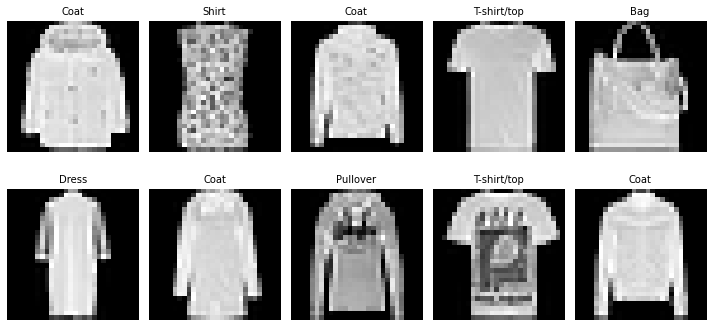

In [31]:
# Affichage de quelques images du dataset
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    # On annule la normalisation pour l'affichage
    image = images[i].squeeze()
    ax.imshow(image, cmap="gray")
    ax.set_title(class_names[labels[i].item()], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Pourquoi utiliser un CNN ?

Dans des exercices précédents, nous utilisions des modèles qui travaillaient surtout avec des variables déjà structurées.

Pour des images, ce type d’approche devient vite limité, car chaque pixel est une variable et l’information spatiale est très importante.

Un **réseau de neurones convolutif (CNN)** est bien adapté à ce type de données, car il peut :

- détecter automatiquement des motifs simples (bords, textures, formes)
- combiner ces motifs en représentations plus complexes 
- exploiter la structure spatiale des images

Autrement dit, au lieu de concevoir manuellement les caractéristiques utiles, le modèle les apprend directement à partir des données.


## 6. Architecture du modèle

Nous allons maintenant définir un premier CNN simple.

Le modèle contiendra généralement :

- une ou plusieurs couches de convolution ;
- des fonctions d’activation non linéaires, comme **ReLU** ;
- des couches de réduction de dimension, comme le **max pooling** ;
- des couches entièrement connectées pour produire la prédiction finale.

L’objectif ici n’est pas de construire un modèle complexe, mais plutôt de comprendre la structure générale d’un pipeline d’apprentissage profond.


In [32]:
# Définition du modèle CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 7. Fonction de perte et optimiseur

Comme pour d’autres modèles supervisés, nous devons préciser :

- **ce que le modèle doit minimiser** : la fonction de perte
- **comment les paramètres seront ajustés** : l’optimiseur

Pour un problème de classification multiclasse comme Fashion MNIST, une fonction de perte adaptée est généralement **CrossEntropyLoss**.

L’optimiseur, quant à lui, met à jour les poids du réseau après chaque itération d’apprentissage.


In [33]:
# Définition de la loss et de l'optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 8. Boucle d’entraînement

Dans certains outils plus classiques, l’entraînement est souvent résumé par un simple appel à `.fit()`.

Avec PyTorch, cette étape est plus explicite. À chaque époque, on répète essentiellement les étapes suivantes :

1. faire passer les données dans le modèle (**forward pass**)
2. calculer l’erreur
3. propager cette erreur vers l’arrière (**backpropagation**)
4. mettre à jour les poids du réseau.

Cette structure est l’un des éléments les plus importants à comprendre dans cet atelier.


In [34]:
# Boucle d'entraînement
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    epoch_val_loss, epoch_val_acc = evaluate_model(model, val_loader, criterion, device)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train loss: {epoch_train_loss:.4f} | Train acc: {epoch_train_acc:.4f} | "
        f"Val loss: {epoch_val_loss:.4f} | Val acc: {epoch_val_acc:.4f}"
    )

Epoch 1/5 | Train loss: 0.5346 | Train acc: 0.8086 | Val loss: 0.3706 | Val acc: 0.8678
Epoch 2/5 | Train loss: 0.3413 | Train acc: 0.8755 | Val loss: 0.3464 | Val acc: 0.8698
Epoch 3/5 | Train loss: 0.2921 | Train acc: 0.8948 | Val loss: 0.2846 | Val acc: 0.8942
Epoch 4/5 | Train loss: 0.2621 | Train acc: 0.9047 | Val loss: 0.2647 | Val acc: 0.9038
Epoch 5/5 | Train loss: 0.2372 | Train acc: 0.9134 | Val loss: 0.2503 | Val acc: 0.9092


## 9. Suivi de l’apprentissage

Pour vérifier que le modèle apprend correctement, nous suivrons quelques mesures pendant l’entraînement, par exemple :

- la perte sur l’ensemble d’entraînement
- la perte sur l’ensemble de validation
- l’exactitude (accuracy)

Cette étape permet aussi de revoir la notion de **surapprentissage** déjà rencontrée dans des contextes similaires.


In [35]:
# Enregistrement de l'évolution de la loss et de l'accuracy
history = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_acc": train_accuracies,
    "val_acc": val_accuracies
}

history

{'train_loss': [0.5345870233597578,
  0.34133764432094715,
  0.29206526838408575,
  0.26207742842038473,
  0.23724885075622135],
 'val_loss': [0.3706202885309855,
  0.3463820360104243,
  0.2845522402524948,
  0.2646770489613215,
  0.2502823411822319],
 'train_acc': [0.8085740740740741,
  0.875462962962963,
  0.8948148148148148,
  0.9047407407407407,
  0.9133888888888889],
 'val_acc': [0.8678333333333333,
  0.8698333333333333,
  0.8941666666666667,
  0.9038333333333334,
  0.9091666666666667]}

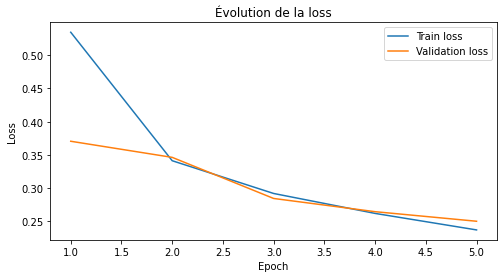

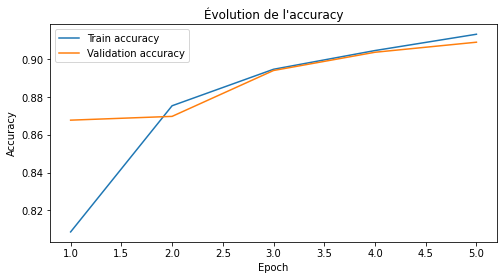

In [36]:
# Visualisation des courbes d'entraînement
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Évolution de la loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_accuracies, label="Train accuracy")
plt.plot(epochs, val_accuracies, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy")
plt.legend()
plt.show()

## 10. Évaluation sur l’ensemble de test

Une fois le modèle entraîné, il faut mesurer sa performance sur des données qu’il n’a jamais vues.

Comme dans des workflows similaires vus auparavant, cette étape sert à estimer la capacité de généralisation du modèle.

Nous calculerons ici :
- l’exactitude globale sur l’ensemble de test
- quelques prédictions individuelles pour mieux interpréter les résultats.


In [37]:
# Évaluation du modèle sur le jeu de test
test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.2670
Test accuracy: 0.9036


## 11. Visualisation de quelques prédictions

Pour mieux comprendre le comportement du modèle, nous allons afficher :

- quelques images de test
- leur classe réelle
- la prédiction du modèle.

Cela permet de repérer plus facilement les cas bien classés et les erreurs fréquentes.


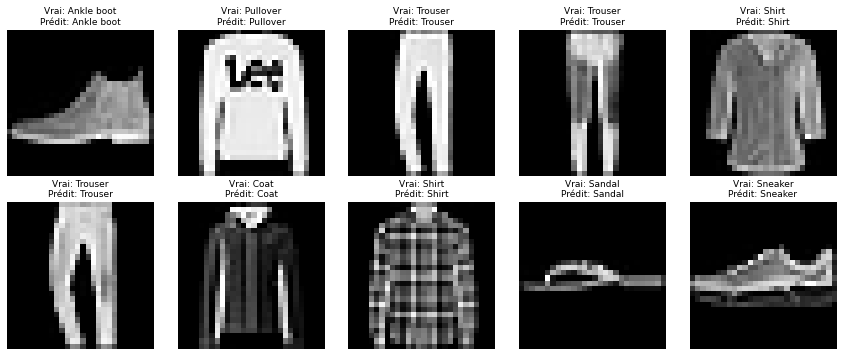

In [38]:
# Affichage de prédictions sur quelques images
model.eval()
images, labels = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    _, predictions = torch.max(outputs, 1)

predictions = predictions.cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = images[i].squeeze()
    true_label = class_names[labels[i].item()]
    pred_label = class_names[predictions[i].item()]

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Vrai: {true_label}\nPrédit: {pred_label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 12. Analyse des résultats

L’accuracy globale donne une première idée de la qualité du modèle, mais elle ne dit pas **quelles classes sont bien reconnues** ni **où le modèle se trompe**.

Pour aller un peu plus loin, nous allons :

- construire une **matrice de confusion** ;
- calculer l’accuracy pour chaque classe ;
- repérer quelques confusions fréquentes.

Cette étape est utile, car deux modèles peuvent avoir une accuracy globale semblable tout en faisant des erreurs très différentes.

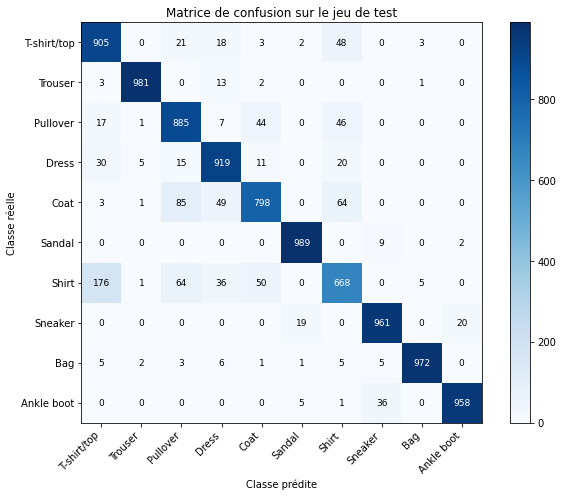

Accuracy par classe :
- T-shirt/top  : 90.50%
- Trouser      : 98.10%
- Pullover     : 88.50%
- Dress        : 91.90%
- Coat         : 79.80%
- Sandal       : 98.90%
- Shirt        : 66.80%
- Sneaker      : 96.10%
- Bag          : 97.20%
- Ankle boot   : 95.80%
Confusions les plus fréquentes :
- Shirt → T-shirt/top : 176 images
- Coat → Pullover : 85 images
- Shirt → Pullover : 64 images


In [39]:
# Matrice de confusion, taux de bonnes prédictions par classe et erreurs les plus fréquentes
model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()

        all_predictions.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

num_classes = len(class_names)
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(all_labels, all_predictions):
    conf_matrix[true_label, pred_label] += 1

# Affichage de la matrice de confusion
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Classe prédite')
ax.set_ylabel('Classe réelle')
ax.set_title('Matrice de confusion sur le jeu de test')

threshold = conf_matrix.max() / 2
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(
            j, i, conf_matrix[i, j],
            ha='center', va='center',
            color='white' if conf_matrix[i, j] > threshold else 'black',
            fontsize=9
        )

plt.tight_layout()
plt.show()

# Accuracy par classe
class_totals = conf_matrix.sum(axis=1)
class_correct = np.diag(conf_matrix)
class_accuracies = class_correct / class_totals

print('Accuracy par classe :')
for class_name, acc in zip(class_names, class_accuracies):
    print(f"- {class_name:<12} : {acc:.2%}")

# Quelques confusions les plus fréquentes (hors diagonale)
off_diagonal = conf_matrix.copy()
np.fill_diagonal(off_diagonal, 0)
flat_indices = np.argsort(off_diagonal, axis=None)[::-1]

print("Confusions les plus fréquentes :")
shown = 0
for idx in flat_indices:
    true_idx, pred_idx = np.unravel_index(idx, off_diagonal.shape)
    count = off_diagonal[true_idx, pred_idx]
    if count == 0 or shown == 3:
        break
    print(f"- {class_names[true_idx]} → {class_names[pred_idx]} : {count} images")
    shown += 1

---
## 🎯 Récapitulatif

Dans ce notebook, nous avons suivi un pipeline complet de classification d’images avec PyTorch :

1. **charger et préparer** le jeu de données Fashion MNIST
2. **explorer** quelques exemples d’images et leurs classes
3. **définir** un réseau de neurones convolutif simple
4. **entraîner** le modèle avec une boucle PyTorch classique
5. **évaluer** ses performances sur validation puis sur test
6. **interpréter** les résultats avec des prédictions individuelles et une matrice de confusion.

### À retenir 🔑

- Un **CNN** exploite la structure spatiale des images, ce qui le rend plus adapté qu’un modèle entièrement connecté pour ce type de tâche.
- Avec PyTorch, la logique d’entraînement est plus explicite : **forward pass → loss → backward pass → update**.
- L’**accuracy globale** est utile, mais elle doit être complétée par une analyse plus fine des erreurs.
- La **matrice de confusion** aide à voir quelles classes se ressemblent le plus pour le modèle.

## 13. Mot de la fin

L’idée n’était pas d’obtenir l’architecture la plus performante possible, mais de voir comment un problème d’images peut être traité de bout en bout avec PyTorch.

À partir d’ici, vous avez les éléments essentiels pour expérimenter avec d’autres architectures, d’autres jeux de données et des entraînements plus poussés.